# 05 · LSTM + attention decoder

The comparison decoder: a *Show, Attend and Tell* style LSTM that re-attends over the image grid at every word (`src/models.py`).

**Held fixed vs the Transformer:** the same image input, the same vocabulary and tied embeddings, a similar size (16.4M vs 17.5M parameters), the same training recipe and the same 4 regularization settings.

**One step:** additive attention with h<sub>t-1</sub> → gated context → `LSTMCell([word; context])` → deep output through the tied embedding.

In [1]:
import json
import shutil
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from torch.utils.data import DataLoader

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import viz
from src.dataset import (EOS_IDX, PAD_IDX, UNK_IDX, SOS_IDX, CaptionDataset, ImageFeatureDataset, LengthBucketSampler,
                         collate_captions, load_processed, reference_captions, split_images)
from src.decoding import generate_captions, greedy_decode
from src.models import LSTMAttentionCaptioner, load_checkpoint
from src.train import fit, run_experiment
from src.utils import caption_scores, set_seed

viz.setup_style()
IMAGE_DIR = ROOT / "data" / "raw" / "Images"
RUNS_CKPT = ROOT / "checkpoints" / "runs"
RESULTS = ROOT / "results" / "lstm"
RESULTS.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda")
features, images, vocab = load_processed(ROOT / "data" / "processed")
train_images, val_images = split_images(images, "train"), split_images(images, "val")
print(f"features {features.shape} | vocab {len(vocab):,} words | train {len(train_images):,} images | val {len(val_images):,} images")

features (31014, 49, 2048) | vocab 7,414 words | train 29,000 images | val 1,014 images


## Configuration
Identical to notebook 02 except for the model itself.

In [2]:
MODEL_CONFIG = dict(vocab_size=len(vocab), d_model=512, hidden_size=1024, attn_dim=512, dropout=0.1)
TRAIN_CONFIG = dict(
    epochs=20,
    batch_size=128,
    lr=3e-4,
    weight_decay=0.01,
    warmup_epochs=1,
    label_smoothing=0.1,
    grad_clip=1.0,
    max_words=40,
    seed=42,
)
RUNS = {
    "baseline": dict(dropout=0.1, weight_decay=0.01),
    "dropout 0.3": dict(dropout=0.3, weight_decay=0.01),
    "dropout 0.3 + wd 0.1": dict(dropout=0.3, weight_decay=0.1),
    "dropout 0.5 + wd 0.1": dict(dropout=0.5, weight_decay=0.1),
}
display(viz.table(pd.DataFrame([{"run": k, **v} for k, v in RUNS.items()]), caption="Runs (same grid as the Transformer)",
                  formats={"dropout": "{:g}", "weight_decay": "{:g}"}))

run,dropout,weight_decay
baseline,0.1,0.01
dropout 0.3,0.3,0.01
dropout 0.3 + wd 0.1,0.3,0.1
dropout 0.5 + wd 0.1,0.5,0.1


## Data

In [3]:
set_seed(TRAIN_CONFIG["seed"])
train_set = CaptionDataset(features, train_images, vocab, TRAIN_CONFIG["max_words"])
val_set = CaptionDataset(features, val_images, vocab, TRAIN_CONFIG["max_words"])
train_loader = DataLoader(train_set, batch_sampler=LengthBucketSampler(train_set.lengths, TRAIN_CONFIG["batch_size"]),
                          collate_fn=collate_captions, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=256, collate_fn=collate_captions, pin_memory=True)
val_image_loader = DataLoader(ImageFeatureDataset(features, val_images), batch_size=256)
val_refs = reference_captions(val_images)
print(f"train pairs {len(train_set):,} -> {len(train_loader):,} steps/epoch | val pairs {len(val_set):,}")

train pairs 145,000 -> 1,132 steps/epoch | val pairs 5,070


## Model

In [4]:
model = LSTMAttentionCaptioner(**MODEL_CONFIG).to(device)


def n_params(*parts):
    return sum(p.numel() for part in parts for p in (part.parameters() if isinstance(part, nn.Module) else [part]))


display(viz.table(pd.DataFrame([
    {"component": "image projection + 2D position (shared design)", "parameters": n_params(model.feat_proj, model.feat_norm, model.row_embed, model.col_embed)},
    {"component": "word embedding (tied with output)", "parameters": n_params(model.tok_embed, model.out_bias)},
    {"component": "additive attention + gate", "parameters": n_params(model.attn_mem, model.attn_hid, model.attn_score, model.gate)},
    {"component": "LSTM cell + state init", "parameters": n_params(model.lstm, model.init_h, model.init_c)},
    {"component": "deep output projection", "parameters": n_params(model.out_proj)},
    {"component": "total", "parameters": n_params(model)},
]), caption="Parameters"))

component,parameters
image projection + 2D position (shared design),"1,057,280"
word embedding (tied with output),"3,803,382"
additive attention + gate,"1,312,769"
LSTM cell + state init,"9,447,424"
deep output projection,"786,944"
total,"16,407,799"


## Sanity checks before training
Initial loss ≈ ln(vocab size), no future leakage, step-by-step decoding identical to the teacher-forced pass, and 16 captions memorised word for word.

In [5]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
feats, caps = [t.to(device) for t in next(iter(train_loader))]
checks = []

model.eval()
with torch.no_grad():
    logits = model(feats, caps[:, :-1])
    init_loss = criterion(logits.flatten(0, 1), caps[:, 1:].flatten()).item()
    checks.append({"check": "initial loss vs ln(V)", "result": f"{init_loss:.3f} vs {np.log(len(vocab)):.3f}",
                   "pass": abs(init_loss - np.log(len(vocab))) < 0.5})

    t = caps.size(1) // 2
    corrupted = caps[:, :-1].clone()
    corrupted[:, t:] = torch.randint(4, len(vocab), corrupted[:, t:].shape, device=device)
    logits2 = model(feats, corrupted)
    unchanged = torch.allclose(logits[:, :t], logits2[:, :t], atol=1e-5)
    changed = not torch.allclose(logits[:, t:], logits2[:, t:], atol=1e-5)
    checks.append({"check": f"corrupt tokens from position {t}: earlier logits unchanged, later changed",
                   "result": f"{unchanged} / {changed}", "pass": unchanged and changed})

    state, stepped = model.init_state(feats), []
    for i in range(caps.size(1) - 1):
        lp, state = model.step(caps[:, : i + 1], state)
        stepped.append(lp)
    max_diff = (torch.stack(stepped, 1) - logits.float().log_softmax(-1)).abs().max().item()
    checks.append({"check": "step-by-step decoding vs teacher-forced forward (max |Δ log-prob|)",
                   "result": f"{max_diff:.2e}", "pass": max_diff < 1e-3})

set_seed(0)
probe = LSTMAttentionCaptioner(**{**MODEL_CONFIG, "dropout": 0.0}).to(device)
probe_opt = torch.optim.AdamW(probe.parameters(), lr=1e-3)
# First caption of 16 different images, skipping captions with <unk> (decoding never emits <unk>).
probe_idx = [i for i in range(0, len(train_set), 5) if UNK_IDX not in train_set.samples[i][1]][:16]
small_f, small_c = [t.to(device) for t in collate_captions([train_set[i] for i in probe_idx])]
for step in range(400):
    with torch.autocast("cuda", dtype=torch.bfloat16):
        loss = criterion(probe(small_f, small_c[:, :-1]).float().flatten(0, 1), small_c[:, 1:].flatten())
    probe_opt.zero_grad()
    loss.backward()
    probe_opt.step()
probe.eval()
recon = [vocab.decode(s) for s in greedy_decode(probe, small_f, max_len=45)]
exact = sum(r == vocab.decode(c[1:]) for r, c in zip(recon, small_c))
checks.append({"check": "overfit 16 captions (16 images) for 400 steps", "result": f"loss {loss.item():.4f}, {exact}/16 reproduced exactly",
               "pass": exact == 16})
del probe, probe_opt

display(viz.table(pd.DataFrame(checks), caption="Sanity checks"))

check,result,pass
initial loss vs ln(V),8.932 vs 8.911,True
"corrupt tokens from position 8: earlier logits unchanged, later changed",True / True,True
step-by-step decoding vs teacher-forced forward (max |Δ log-prob|),0.00e+00,True
overfit 16 captions (16 images) for 400 steps,"loss 0.0004, 16/16 reproduced exactly",True


## Training runs

In [6]:
histories = {}
for name, overrides in RUNS.items():
    slug = name.replace(" + ", "_").replace(" ", "")
    model_cfg = {**MODEL_CONFIG, "dropout": overrides["dropout"]}
    train_cfg = {**TRAIN_CONFIG, **overrides}
    live = viz.LiveTable(
        f"Run: {name}",
        {"epoch": "epoch", "lr_start": "lr", "train_loss": "train loss", "val_loss": "val loss",
         "val_bleu4": "BLEU-4", "val_cider": "CIDEr", "seconds": "sec"},
        maximize=["val_cider"], minimize=["val_loss"], formats={"lr_start": "{:.1e}", "seconds": "{:.0f}"},
    )

    def train_fn(model, train_cfg=train_cfg, model_cfg=model_cfg, slug=slug, live=live):
        return fit(
            model, train_loader, val_loader, val_image_loader, val_refs, vocab, device,
            epochs=train_cfg["epochs"], lr=train_cfg["lr"], weight_decay=train_cfg["weight_decay"],
            warmup_epochs=train_cfg["warmup_epochs"], label_smoothing=train_cfg["label_smoothing"],
            grad_clip=train_cfg["grad_clip"], ckpt_path=RUNS_CKPT / f"lstm_{slug}.pt",
            run_config={"model": model_cfg, "train": train_cfg}, on_epoch_end=live,
        )

    history, cached = run_experiment(
        name, lambda cfg=model_cfg: LSTMAttentionCaptioner(**cfg).to(device), train_fn,
        ckpt_path=RUNS_CKPT / f"lstm_{slug}.pt", history_path=RESULTS / "runs" / slug / "history.json",
        seed=TRAIN_CONFIG["seed"],
    )
    if cached:
        live(history)
    histories[name] = history

epoch,lr,train loss,val loss,BLEU-4,CIDEr,sec
1,2.7e-07,5.702,4.037,0.181,0.312,86
2,3.0e-04,4.386,3.443,0.185,0.384,61
3,3.0e-04,4.085,3.245,0.196,0.402,63
4,2.9e-04,3.930,3.154,0.188,0.400,54
5,2.8e-04,3.816,3.083,0.185,0.416,48
6,2.7e-04,3.723,3.052,0.201,0.441,48
7,2.5e-04,3.640,3.030,0.211,0.435,48
8,2.3e-04,3.565,3.039,0.217,0.442,49
9,2.1e-04,3.494,3.041,0.218,0.441,48
10,1.9e-04,3.428,3.052,0.195,0.432,48


epoch,lr,train loss,val loss,BLEU-4,CIDEr,sec
1,2.7e-07,5.727,4.065,0.185,0.311,49
2,3.0e-04,4.434,3.470,0.184,0.367,49
3,3.0e-04,4.145,3.271,0.196,0.384,48
4,2.9e-04,4.000,3.179,0.188,0.389,48
5,2.8e-04,3.897,3.107,0.191,0.413,48
6,2.7e-04,3.818,3.061,0.204,0.425,48
7,2.5e-04,3.748,3.036,0.212,0.434,48
8,2.3e-04,3.689,3.025,0.217,0.449,49
9,2.1e-04,3.633,3.012,0.217,0.444,48
10,1.9e-04,3.582,3.016,0.200,0.436,48


epoch,lr,train loss,val loss,BLEU-4,CIDEr,sec
1,2.7e-07,5.728,4.068,0.184,0.309,48
2,3.0e-04,4.436,3.475,0.186,0.369,49
3,3.0e-04,4.149,3.276,0.195,0.381,48
4,2.9e-04,4.006,3.186,0.189,0.386,48
5,2.8e-04,3.906,3.109,0.184,0.398,48
6,2.7e-04,3.828,3.066,0.203,0.429,48
7,2.5e-04,3.762,3.038,0.209,0.422,48
8,2.3e-04,3.705,3.025,0.219,0.442,48
9,2.1e-04,3.653,3.011,0.217,0.447,48
10,1.9e-04,3.604,3.017,0.204,0.442,49


epoch,lr,train loss,val loss,BLEU-4,CIDEr,sec
1,2.7e-07,5.768,4.118,0.181,0.297,48
2,3.0e-04,4.506,3.519,0.194,0.363,49
3,3.0e-04,4.233,3.325,0.192,0.376,48
4,2.9e-04,4.099,3.232,0.172,0.357,48
5,2.8e-04,4.007,3.160,0.187,0.394,47
6,2.7e-04,3.938,3.107,0.201,0.410,48
7,2.5e-04,3.881,3.074,0.210,0.412,48
8,2.3e-04,3.834,3.061,0.219,0.436,48
9,2.1e-04,3.790,3.033,0.223,0.436,48
10,1.9e-04,3.751,3.027,0.206,0.437,48


## Comparing the runs

run,dropout,weight decay,best epoch,val CIDEr,val BLEU-4,lowest val loss,at epoch,final train loss,minutes
baseline,0.1,0.01,8,0.442,0.217,3.030,7,3.075,17.2
dropout 0.3,0.3,0.01,16,0.463,0.212,3.011,11,3.319,16.0
dropout 0.3 + wd 0.1,0.3,0.1,14,0.459,0.215,3.007,12,3.345,16.0
dropout 0.5 + wd 0.1,0.5,0.1,20,0.463,0.220,2.999,17,3.545,15.9


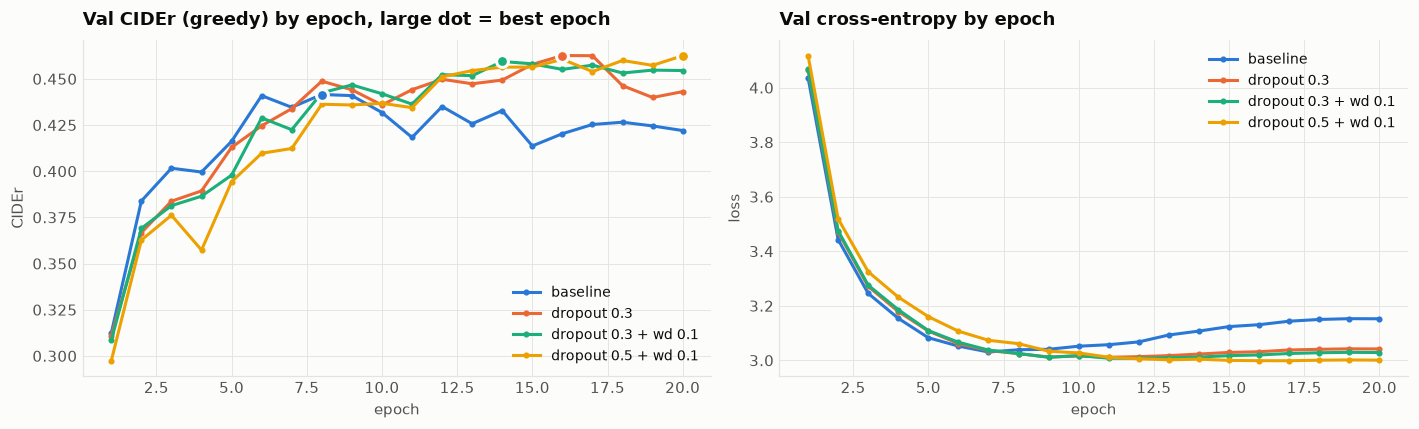

In [7]:
rows = []
for name, hist in histories.items():
    h = pd.DataFrame(hist)
    best, low = h.loc[h.val_cider.idxmax()], h.loc[h.val_loss.idxmin()]
    rows.append({
        "run": name, "dropout": RUNS[name]["dropout"], "weight decay": RUNS[name]["weight_decay"],
        "best epoch": int(best.epoch), "val CIDEr": best.val_cider, "val BLEU-4": best.val_bleu4,
        "lowest val loss": low.val_loss, "at epoch": int(low.epoch),
        "final train loss": h.train_loss.iloc[-1], "minutes": h.seconds.sum() / 60,
    })
summary = pd.DataFrame(rows)
summary.to_csv(RESULTS / "runs_summary.csv", index=False)
display(viz.table(summary, maximize=["val CIDEr", "val BLEU-4"], minimize=["lowest val loss"],
                  caption="LSTM + attention runs (val set, greedy decoding)",
                  formats={"dropout": "{:g}", "weight decay": "{:g}", "minutes": "{:.1f}"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, hist in histories.items():
    h = pd.DataFrame(hist)
    line, = axes[0].plot(h.epoch, h.val_cider, marker="o", ms=3, label=name)
    b = h.loc[h.val_cider.idxmax()]
    axes[0].scatter(b.epoch, b.val_cider, s=60, color=line.get_color(), edgecolor=viz.SURFACE, linewidth=2, zorder=3)
    axes[1].plot(h.epoch, h.val_loss, marker="o", ms=3, label=name)
axes[0].set(title="Val CIDEr (greedy) by epoch, large dot = best epoch", xlabel="epoch", ylabel="CIDEr")
axes[1].set(title="Val cross-entropy by epoch", xlabel="epoch", ylabel="loss")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "runs_comparison.png")
plt.show()

## Selected model
The best val CIDEr run is copied to `checkpoints/lstm_xe.pt`.

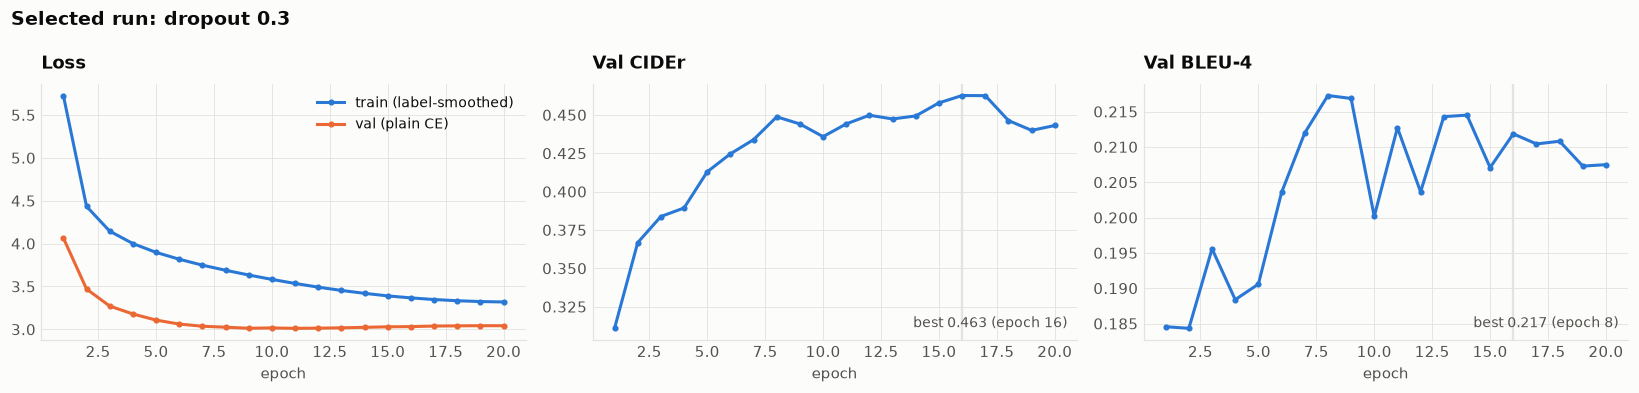

In [8]:
best_run = summary.loc[summary["val CIDEr"].idxmax(), "run"]
best_slug = best_run.replace(" + ", "_").replace(" ", "")
shutil.copy(RUNS_CKPT / f"lstm_{best_slug}.pt", ROOT / "checkpoints" / "lstm_xe.pt")
(RESULTS / "selected_run.json").write_text(json.dumps({"run": best_run, **RUNS[best_run]}, indent=2))

model, ckpt = load_checkpoint(ROOT / "checkpoints" / "lstm_xe.pt", device)
viz.note(f"Selected run: <b>{best_run}</b>, epoch {ckpt['epoch']}, "
         f"val CIDEr <b>{ckpt['val_scores']['CIDEr']:.3f}</b>, BLEU-4 {ckpt['val_scores']['BLEU-4']:.3f}")

h = pd.DataFrame(histories[best_run])
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].plot(h.epoch, h.train_loss, marker="o", ms=3, label="train (label-smoothed)")
axes[0].plot(h.epoch, h.val_loss, marker="o", ms=3, label="val (plain CE)")
axes[0].set(title="Loss", xlabel="epoch")
axes[0].legend()
for ax, col, title in [(axes[1], "val_cider", "Val CIDEr"), (axes[2], "val_bleu4", "Val BLEU-4")]:
    ax.plot(h.epoch, h[col], marker="o", ms=3, color=viz.SERIES[0])
    ax.axvline(ckpt["epoch"], color=viz.GRID, lw=1.5, zorder=0)
    ax.text(0.98, 0.05, f"best {h[col].max():.3f} (epoch {int(h.loc[h[col].idxmax(), 'epoch'])})",
            transform=ax.transAxes, ha="right", color=viz.INK_2, fontsize=9)
    ax.set(title=title, xlabel="epoch")
fig.suptitle(f"Selected run: {best_run}", x=0.01, ha="left", fontsize=12.5, weight="bold")
plt.tight_layout()
plt.savefig(RESULTS / "training_curves.png")
plt.show()

## First look: LSTM vs Transformer on val (greedy)
The full ablation, with test numbers and significance, is in notebooks 04 and 07.

decoder,parameters,BLEU-1,BLEU-2,BLEU-3,BLEU-4,CIDEr
Transformer,"17,506,550",0.656,0.470,0.330,0.231,0.476
LSTM + attention,"16,407,799",0.630,0.444,0.307,0.212,0.463


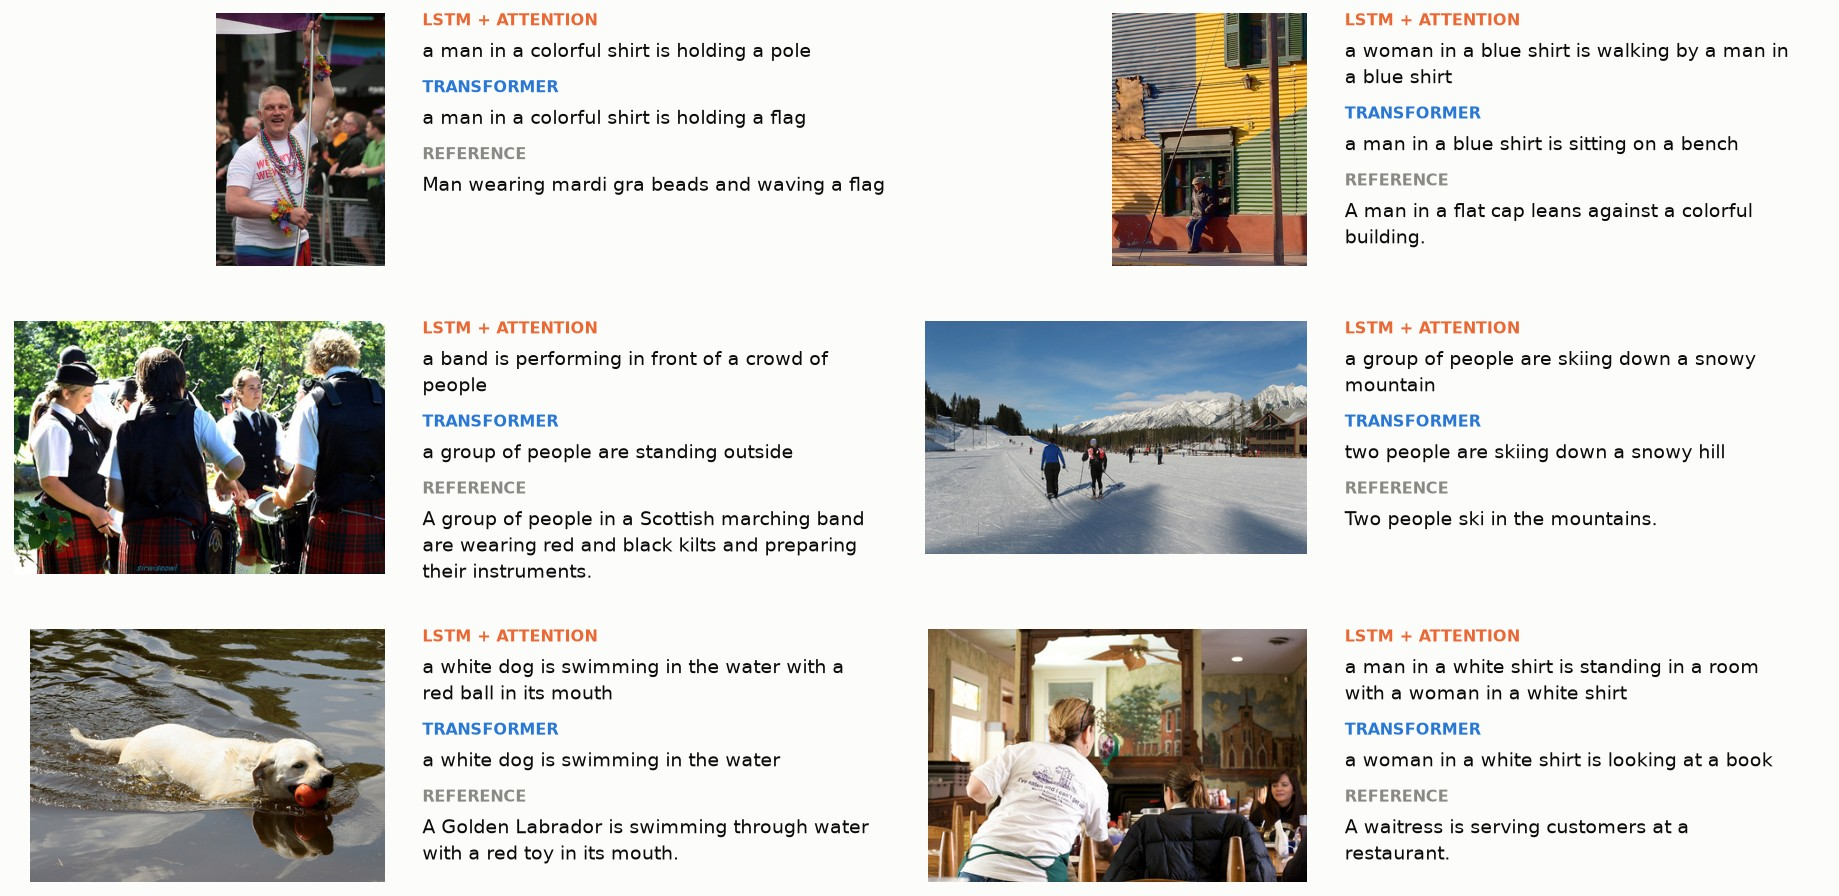

In [9]:
lstm_caps = generate_captions(model, val_image_loader, vocab, device)
if not (ROOT / "checkpoints" / "transformer_xe.pt").exists():
    raise SystemExit("Run notebook 02 first: checkpoints/transformer_xe.pt is missing.")
transformer, t_ckpt = load_checkpoint(ROOT / "checkpoints" / "transformer_xe.pt", device)
trans_caps = generate_captions(transformer, val_image_loader, vocab, device)
display(viz.table(pd.DataFrame([
    {"decoder": "Transformer", "parameters": n_params(transformer), **caption_scores(val_refs, trans_caps)},
    {"decoder": "LSTM + attention", "parameters": n_params(model), **caption_scores(val_refs, lstm_caps)},
]), maximize=["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4", "CIDEr"], caption="Val set, greedy decoding"))

rng = np.random.default_rng(11)
examples = []
for img in rng.choice(val_images, 6, replace=False):
    examples.append({"filename": img["filename"], "captions": [
        ("LSTM + attention", lstm_caps[img["filename"]]), ("Transformer", trans_caps[img["filename"]]),
        ("reference", rng.choice(img["captions"]))]})
viz.show_captions(examples, IMAGE_DIR, colors={"LSTM + attention": viz.SERIES[1], "Transformer": viz.SERIES[0], "reference": viz.INK_3})

## Where the LSTM looks
One attention distribution per word, so these maps read more clearly than the Transformer's 24-head average.

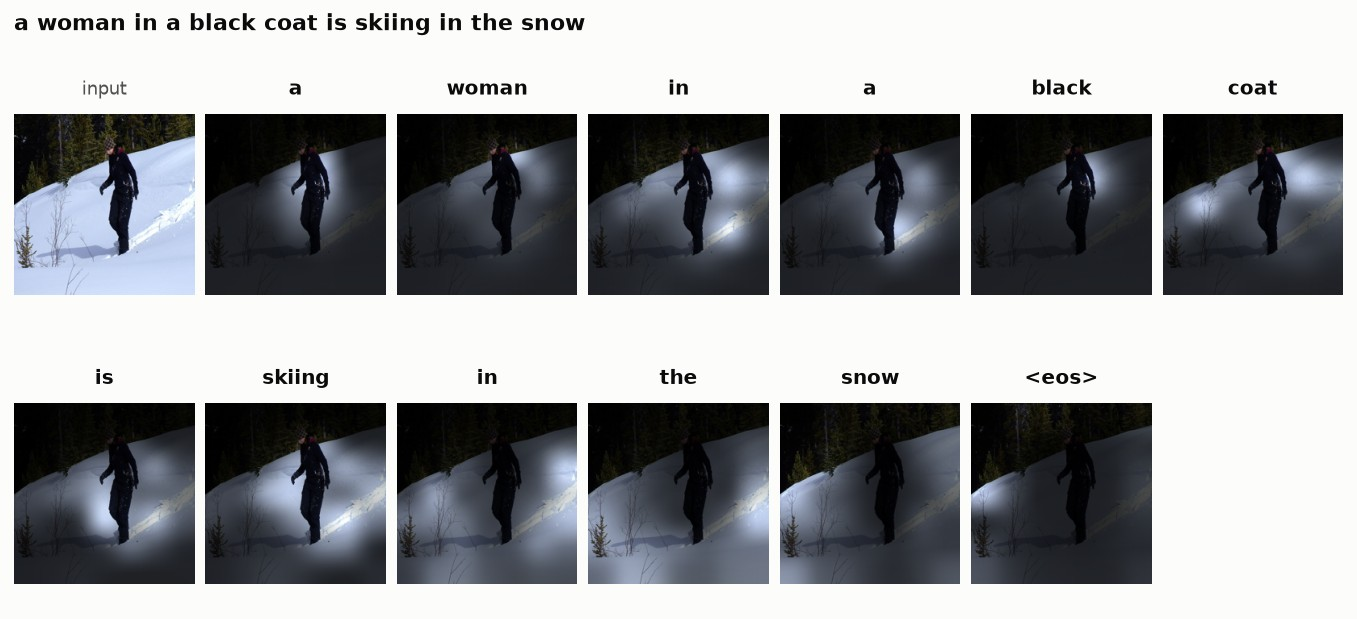

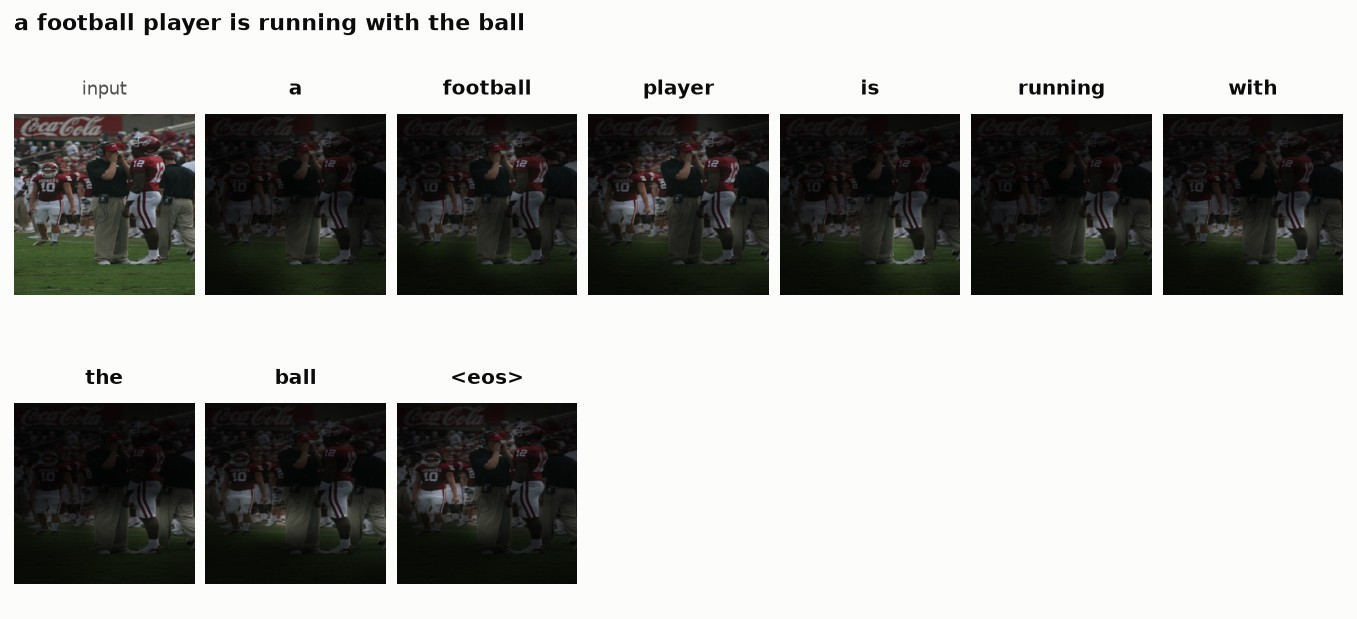

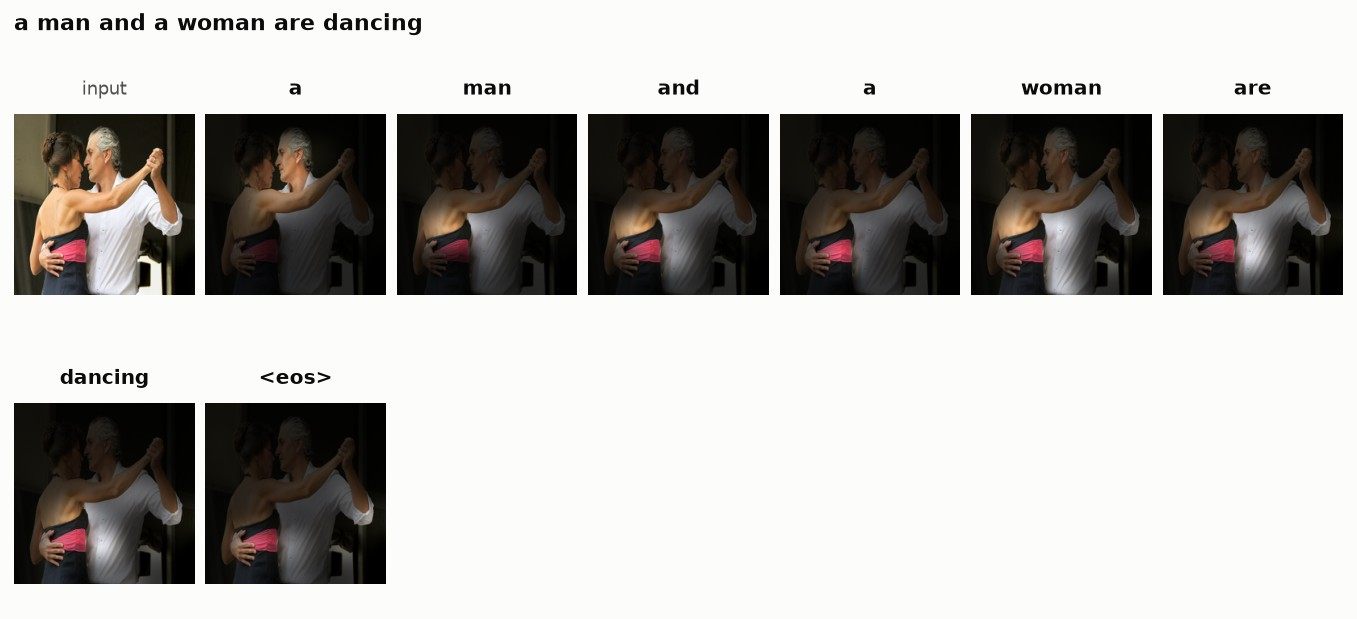

In [10]:
for img in np.random.default_rng(3).choice(val_images, 3, replace=False):
    feat = torch.from_numpy(np.array(features[img["feat_idx"]]))[None].to(device).float()
    ids = greedy_decode(model, feat)[0]
    with torch.no_grad():
        attn = model.attention_maps(feat, torch.tensor([[SOS_IDX] + ids], device=device))[0].cpu().numpy()
    words = [vocab.itos[i] for i in ids] + ["<eos>"]
    viz.show_attention(IMAGE_DIR / img["filename"], words, attn, title=" ".join(words[:-1]))

## Summary

- All checks pass, including an exact match between step-by-step decoding and the teacher-forced pass.
- 16.4M parameters vs the Transformer's 17.5M; about 1.3× slower per epoch (48 s vs 36 s).
- Best run (dropout 0.3) reaches val CIDEr **0.463 (+4.8%)**. The LSTM varies less across settings (0.442–0.463) than the Transformer (0.429–0.476).
- On val with greedy decoding the Transformer leads: CIDEr 0.476 vs 0.463, BLEU-4 0.231 vs 0.212.